# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [3]:
# Lectura datos, relación variables, mapas de correlación...
pyme = pd.read_csv (r'data\Advertising.csv')

In [4]:
pyme.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newpaper    200 non-null    str    
 4   sales       200 non-null    float64
dtypes: float64(3), int64(1), str(1)
memory usage: 7.9 KB


In [5]:
pyme.head(5)
pyme = pyme.drop ('Unnamed: 0', axis=1)

In [6]:
pyme.head(5)

,TV,radio,newpaper,sales
0,230.1,37.8,6s9.2,22100.0
1,44.5,39.3,45.1,10400.0
2,17.2,45.9,69.3,9300.0
3,151.5,41.3,58.5,18500.0
4,180.8,10.8,58.4,12900.0


In [7]:
# No sé qué quería poner ahí si 69.2 o 609. Elimino esa fila
pyme = pyme [1:]



In [8]:
pyme ['newpaper'] = pyme['newpaper'].astype(float)

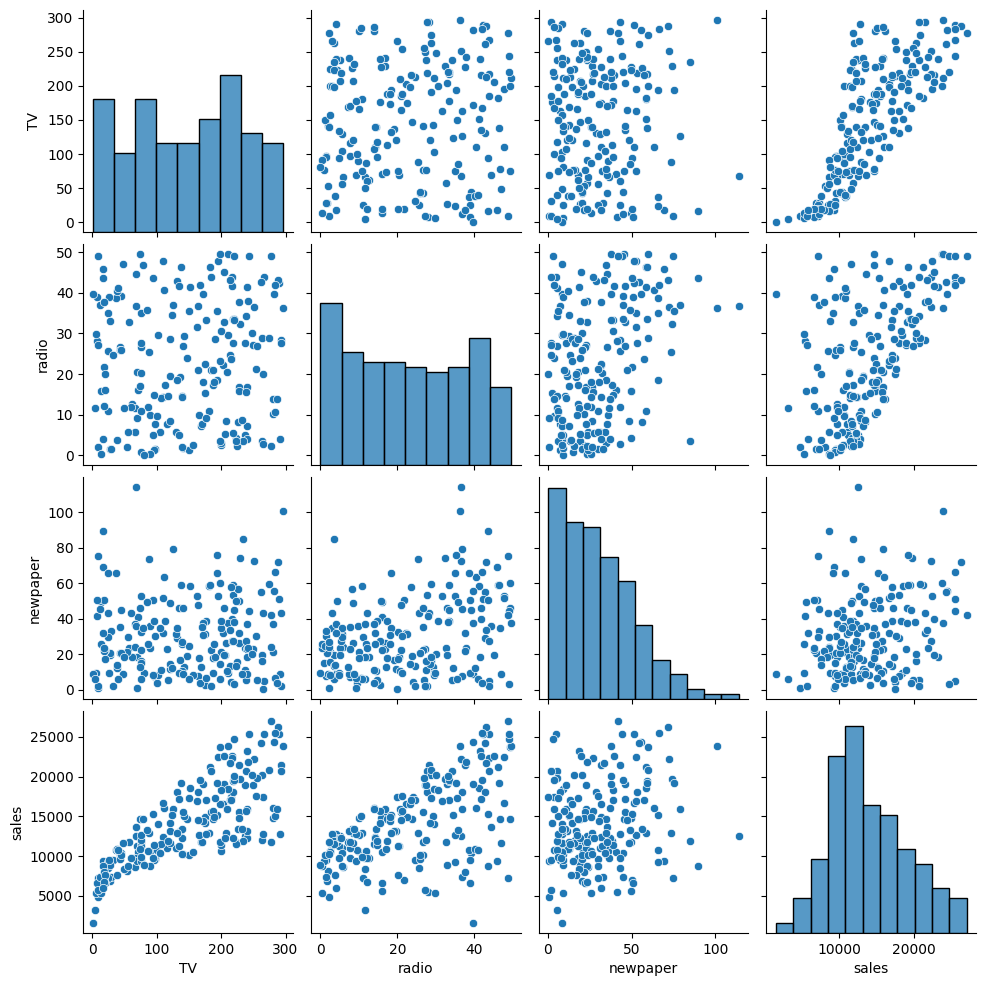

In [9]:
# En pairplot a ver cómo se relacionan las variables
sns.pairplot(pyme)

<Axes: >

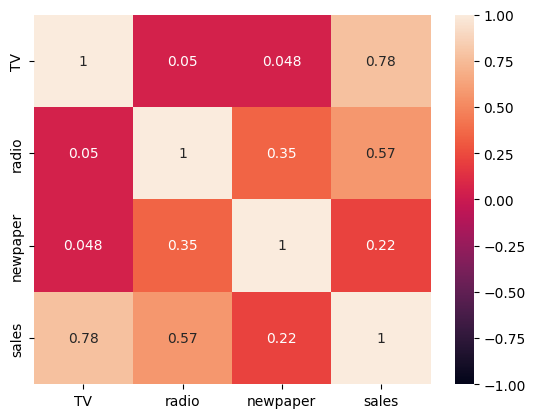

In [10]:
sns.heatmap(pyme.corr(), annot=True, vmax=1, vmin=-1)

## Modelado

In [11]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

# Empezamos por una regresión lineal

#Por convención la X es mayúscula y la y minúscula
y = pyme ['sales'] # lo que quiero predecir
# la variable de entrada. Tiene que ser un dataframe, por eso dobles corchetes. Si no, da error
X = pyme [['TV','radio','newpaper']] 
#creamos los 4 grupos para train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)
# creamos el  objeto
lm = LinearRegression() 
#lo entrenamos
lm.fit (X_train, y_train)
predictions_test = lm.predict(X_test)

In [12]:
#Medimos. Voy a medir MSE y R2
from sklearn.metrics import r2_score
from sklearn import metrics
import numpy as np

predictions_train = lm.predict (X_train)

# Es el error de base. Sin hacer nada deberíamos de 
baseline_error = mean_squared_error (y_test, predictions_test)

print("Train MSE:", metrics.mean_squared_error(y_train, predictions_train))
print("Test MSE:", metrics.mean_squared_error(y_test, predictions_test))
print("Train RMSE:", np.sqrt (metrics.mean_squared_error(y_train, predictions_train)))
print("Test RMSE:", np.sqrt (metrics.mean_squared_error(y_test, predictions_test)))
print("Train R2:", r2_score (y_train, predictions_train))
print("Test R2:", r2_score (y_test, predictions_test))

Train MSE: 2872614.923945353
Test MSE: 2520107.84015061
Train RMSE: 1694.8790292954104
Test RMSE: 1587.48475273012
Train R2: 0.8987751617556998
Test R2: 0.8733836445096173


In [13]:
#  Ya es un modelo bastante bueno! El R2 es muy alto.
print(lm.intercept_)
print(lm.coef_)

2660.4342930761995
[ 46.90895387 188.96744505   0.21571305]


In [14]:
# Lasso y Ridge son válidos para cuando hay mucho overfit. No es el caso. El siguiente paso lógico
# sería complejizarla (una polinómica) y luego regularizarla y simplificarla

In [15]:
# Buena práctica: Crear un dataframe para ir guardando las métricas de cada una de las pruebas.
# Jose metió todo en un bucle. Mirar.

### Modelos Polinómicos

In [20]:
# creamos los features para un polinomio de grado 2
poly_feats = PolynomialFeatures(degree = 2)
poly_feats.fit(X)
X_poly = poly_feats.transform(X)

#separamos la parte de train y test
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.20, random_state = 42)

#Creamos el modelo y entrenamos
pol_model= LinearRegression()
pol_model.fit(X_train, y_train)

#Predicciones
pred_test = pol_model.predict (X_test)
pred_train = pol_model.predict (X_train)



In [21]:
#Medimos resultados
print("Train MSE:", metrics.mean_squared_error(y_train, pred_train))
print("Test MSE:", metrics.mean_squared_error(y_test, pred_test))
print("Train R2:", r2_score (y_train, pred_train))
print("Test R2:", r2_score (y_test, pred_test))

Train MSE: 375169.7781501895
Test MSE: 392368.4905963643
Train R2: 0.98677981521615
Test R2: 0.9802864514378856


In [ ]:
#Intentar regularizarlo para simplificarlo - tenía que haberlo 

from sklearn.linear_model import Ridge
import numpy as np
# RIDGE 
#Prueba en bruto con muchos alphas
n_alphas = 100
alphas = np.logspace(-4, 3, n_alphas)

coef_ridge = []
err_ridge = []
baseline = []

for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    
    coef_ridge.append(ridge.coef_)
    
    y_pred = ridge.predict(X_test)
    ridge_error = metrics.mean_squared_error(y_pred, y_test)
    
    err_ridge.append(ridge_error)      # ahora sí dentro del bucle
    baseline.append(baseline_error)

# Recuperar el alpha con menor error
idx_min = np.argmin(err_ridge)         # índice del error mínimo
mejor_alpha = alphas[idx_min]          # alpha correspondiente
mejor_error = err_ridge[idx_min]       # el error mínimo

In [ ]:
ridgeR = Ridge(alpha = mejor_alpha) 
ridgeR.fit(X_train, y_train) 

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, ridgeR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, ridgeR.predict(X_test)))
# Mejora muy poquito

Train MSE: 376060.4790
Test MSE: 387108.2455


In [24]:
#Probar LASSO
from sklearn.linear_model import Lasso
lasso = Lasso(fit_intercept=False)

coef_lasso = []
err_lasso = []

for a in alphas:
    lasso.set_params(alpha=a)
    lasso.fit(X_train, y_train)
    coef_lasso.append(lasso.coef_)
    y_pred = lasso.predict(X_test)
    lasso_error = metrics.mean_squared_error(y_pred, y_test)    
    err_lasso.append(lasso_error)

idx_min = np.argmin(err_lasso)         # índice del error mínimo
mejor_alpha = alphas[idx_min]          # alpha correspondiente
mejor_error = err_ridge[idx_min]       # el error mínimo

c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.983e+07, tolerance: 3.664e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.983e+07, tolerance: 3.664e+06
  model = cd_fast.enet_coordinate_descent(
c:\Users\NaiaJon\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check t

In [25]:
lassoR = Lasso(alpha = mejor_alpha) 
lassoR.fit(X_train, y_train) 

print("Train MSE: %0.4f" % metrics.mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE: %0.4f" % metrics.mean_squared_error(y_test, lassoR.predict(X_test)))

Train MSE: 375169.7782
Test MSE: 392368.4873


In [18]:
#Probar un grado 3
# creamos los features para un polinomio de grado 2
poly_feats = PolynomialFeatures(degree = 3)
# 1º separar

#separamos la parte de train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

#luego crear los features
X_train_poly = poly_feats.fit_transform (X_train)
X_test_poly = poly_feats.transform(X_test)


#Creamos el modelo y entrenamos
pol_model= LinearRegression()
pol_model.fit(X_train_poly, y_train)

#Predicciones
pred_test = pol_model.predict (X_test_poly)
pred_train = pol_model.predict (X_train_poly)


In [19]:
print("Train MSE:", metrics.mean_squared_error(y_train, pred_train))
print("Test MSE:", metrics.mean_squared_error(y_test, pred_test))
print("Train R2:", r2_score (y_train, pred_train))
print("Test R2:", r2_score (y_test, pred_test))

Train MSE: 206822.00756363495
Test MSE: 302763.2105181219
Train R2: 0.9927120324807626
Test R2: 0.9847884389383587


## Resultados

In [42]:
# Interpreta, resume y destaca los puntos importantes de los resultados.
print(pol_model.intercept_)
print(pol_model.coef_)

4861.271090401131
[ 0.00000000e+00  5.29163825e+01  1.70988058e+01  1.47073590e+01
 -1.11281111e-01  1.13799290e+00 -7.97885506e-02  3.28567914e-03
  1.62133080e-01 -1.40651485e-02]


In [46]:
poly_feats.get_feature_names_out(['TV','radio','newpaper'])

array(['1', 'TV', 'radio', 'newpaper', 'TV^2', 'TV radio', 'TV newpaper',
       'radio^2', 'radio newpaper', 'newpaper^2'], dtype=object)

In [ ]:
# Esto es una cosa de Claude. Yo ni idea. Lo dejo aquí escrito para verlo en otro momento
# Ventas = 4861.27
        #  + 0·1
        #  + 52.92·TV
        #  + 17.10·radio
        #  + 14.71·newspaper
        #  - 0.111·TV²
        #  + 1.138·TV·radio
        #  - 0.0798·TV·newspaper
        #  + 0.00329·radio²
        #  + 0.1621·radio·newspaper
        #  - 0.01407·newspaper²
# TV tiene el mayor impacto directo (52.92), pero su efecto decrece a medida que aumenta (-0.111·TV²)
# Radio y TV se potencian mutuamente — el término TV·radio (1.138) es positivo, 
# invertir en ambos a la vez es más efectivo
# Newspaper tiene el menor impacto y además su término cuadrático es negativo, 